In [1]:
import torch
import numpy as np

def cutmix_data(x, y, alpha=1.0):
    '''Apply CutMix augmentation'''
    lam = np.random.beta(alpha, alpha)
    rand_index = torch.randperm(x.size()[0]).to(x.device)
    target_a = y
    target_b = y[rand_index]
    
    bbx1, bby1, bbx2, bby2 = rand_bbox(x.size(), lam)
    x[:, :, bbx1:bbx2, bby1:bby2] = x[rand_index, :, bbx1:bbx2, bby1:bby2]
    
    # Adjust lambda to match the exact area ratio
    lam = 1 - ((bbx2 - bbx1) * (bby2 - bby1) / (x.size()[-1] * x.size()[-2]))
    return x, target_a, target_b, lam

def rand_bbox(size, lam):
    '''Generate random bounding box'''
    W = size[2]
    H = size[3]
    cut_rat = np.sqrt(1. - lam)
    cut_w = int(W * cut_rat)
    cut_h = int(H * cut_rat)

    # uniform
    cx = np.random.randint(W)
    cy = np.random.randint(H)

    bbx1 = np.clip(cx - cut_w // 2, 0, W)
    bby1 = np.clip(cy - cut_h // 2, 0, H)
    bbx2 = np.clip(cx + cut_w // 2, 0, W)
    bby2 = np.clip(cy + cut_h // 2, 0, H)

    return bbx1, bby1, bbx2, bby2

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision import models
from torch.utils.data import DataLoader
from torch.utils.tensorboard import SummaryWriter
import numpy as np

In [ ]:
# ============ Config ============
experiment_name = "cutmix"
log_dir = f"runs/{experiment_name}"
save_path = f"runs/{experiment_name}/best.pth"
num_epochs = 40
batch_size = 64
learning_rate = 0.001
cutmix_prob = 0.5
cutmix_alpha = 1.0
# ================================

# 1. Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 2. TensorBoard SummaryWriter
writer = SummaryWriter(log_dir)

# 3. Transform 
transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),        # Slight random shift
    transforms.RandomHorizontalFlip(),           # Horizontal flip with 50% chance
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), 
                         (0.5, 0.5, 0.5))
])


# 4. Dataset & DataLoader
train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4)
val_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=4)

# 5. Model (fix warning: use weights=None)
model = models.resnet18(weights=None)
model.fc = nn.Linear(model.fc.in_features, 10)
model.to(device)

# 6. Loss and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# 7. Evaluation function
def evaluate():
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return correct / total

# 8. Train one epoch with CutMix
def train_one_epoch(epoch):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for i, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)

        r = np.random.rand()
        if r < cutmix_prob:
            lam = np.random.beta(cutmix_alpha, cutmix_alpha)
            rand_index = torch.randperm(images.size()[0]).to(device)
            target_a = labels
            target_b = labels[rand_index]
            bbx1, bby1, bbx2, bby2 = rand_bbox(images.size(), lam)
            images[:, :, bbx1:bbx2, bby1:bby2] = images[rand_index, :, bbx1:bbx2, bby1:bby2]
            lam = 1 - ((bbx2 - bbx1) * (bby2 - bby1) / (images.size(-1) * images.size(-2)))
            outputs = model(images)
            loss = lam * criterion(outputs, target_a) + (1 - lam) * criterion(outputs, target_b)
        else:
            outputs = model(images)
            loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (preds == labels).sum().item()

    avg_loss = running_loss / len(train_loader)
    train_acc = correct / total
    val_acc = evaluate()

    writer.add_scalar("Loss/train", avg_loss, epoch)
    writer.add_scalar("Accuracy/train", train_acc, epoch)
    writer.add_scalar("Accuracy/val", val_acc, epoch)
    print(f"Epoch [{epoch+1}] Train Loss: {avg_loss:.4f}, Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}")
    return val_acc

# 9. Random bbox helper (used by CutMix)
def rand_bbox(size, lam):
    W = size[2]
    H = size[3]
    cut_rat = np.sqrt(1. - lam)
    cut_w = int(W * cut_rat)
    cut_h = int(H * cut_rat)

    cx = np.random.randint(W)
    cy = np.random.randint(H)

    bbx1 = np.clip(cx - cut_w // 2, 0, W)
    bby1 = np.clip(cy - cut_h // 2, 0, H)
    bbx2 = np.clip(cx + cut_w // 2, 0, W)
    bby2 = np.clip(cy + cut_h // 2, 0, H)

    return bbx1, bby1, bbx2, bby2

# 10. Training loop with model checkpointing
best_val_acc = 0.0
for epoch in range(num_epochs):
    val_acc = train_one_epoch(epoch)
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), save_path)
        print(f"✅ Best model saved with val acc: {best_val_acc:.4f}")

writer.close()

Epoch [1] Train Loss: 1.8348, Train Acc: 0.3512, Val Acc: 0.4841
✅ Best model saved with val acc: 0.4841
Epoch [2] Train Loss: 1.5562, Train Acc: 0.4659, Val Acc: 0.5839
✅ Best model saved with val acc: 0.5839
Epoch [3] Train Loss: 1.4470, Train Acc: 0.5197, Val Acc: 0.6418
✅ Best model saved with val acc: 0.6418
Epoch [4] Train Loss: 1.3696, Train Acc: 0.5381, Val Acc: 0.6517
✅ Best model saved with val acc: 0.6517
Epoch [5] Train Loss: 1.2977, Train Acc: 0.5724, Val Acc: 0.6529
✅ Best model saved with val acc: 0.6529
Epoch [6] Train Loss: 1.2619, Train Acc: 0.5839, Val Acc: 0.7092
✅ Best model saved with val acc: 0.7092
Epoch [7] Train Loss: 1.2343, Train Acc: 0.5926, Val Acc: 0.6807
Epoch [8] Train Loss: 1.2059, Train Acc: 0.6014, Val Acc: 0.7017
Epoch [9] Train Loss: 1.1551, Train Acc: 0.6235, Val Acc: 0.7273
✅ Best model saved with val acc: 0.7273
Epoch [10] Train Loss: 1.1187, Train Acc: 0.6447, Val Acc: 0.7343
✅ Best model saved with val acc: 0.7343
Epoch [11] Train Loss: 1.1244

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

def evaluate_model(model_path, model_name, device='cuda'):
    # Define transform for test set
    test_transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), 
                             (0.5, 0.5, 0.5))
    ])

    # CIFAR-10 test set
    test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=test_transform)
    test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)

    # Load model
    from torchvision import models
    model = models.resnet18(weights=None)
    model.fc = nn.Linear(model.fc.in_features, 10)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.to(device)
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    # Compute confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=test_dataset.classes)

    # Plot
    plt.figure(figsize=(8, 6))
    disp.plot(cmap='Blues', xticks_rotation=45)
    plt.title(f'Confusion Matrix - {model_name}')
    plt.grid(False)
    plt.show()


<Figure size 800x600 with 0 Axes>

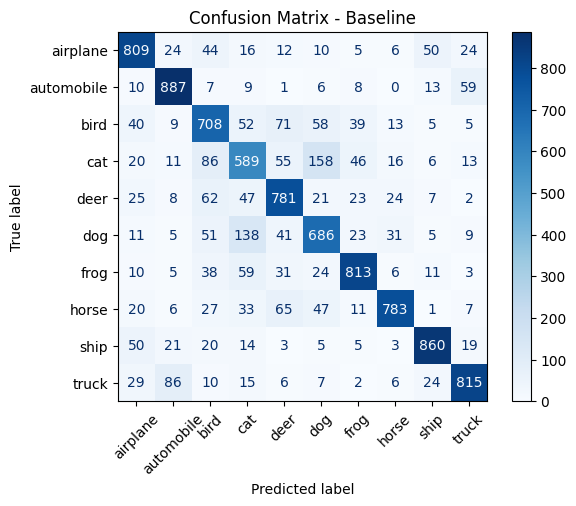

<Figure size 800x600 with 0 Axes>

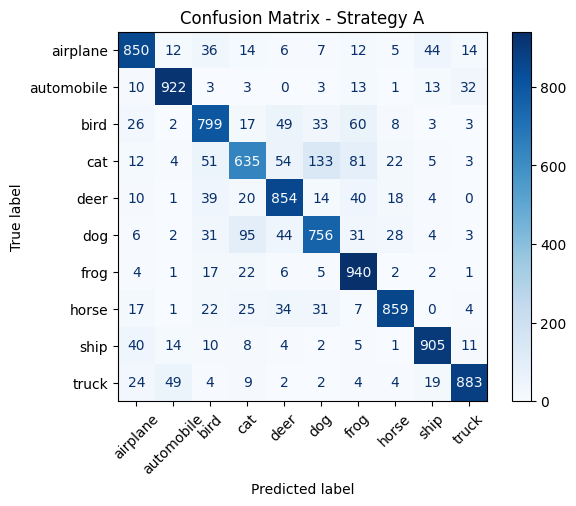

<Figure size 800x600 with 0 Axes>

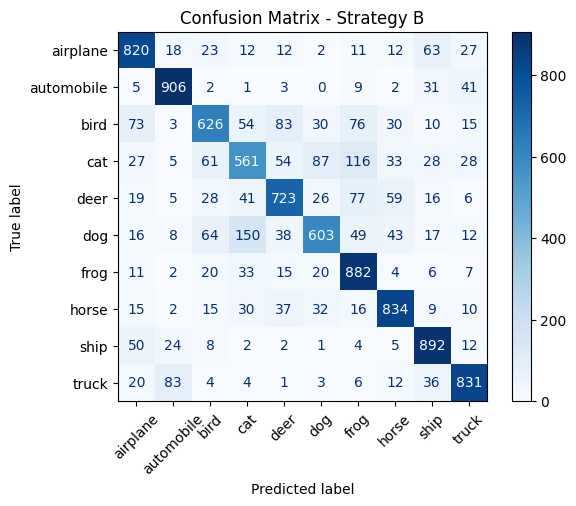

In [6]:
evaluate_model("runs/baseline/best.pth", model_name="Baseline")
evaluate_model("runs/cutmix/best.pth", model_name="Strategy A")
evaluate_model("runs/strong_aug/best.pth", model_name="Strategy B")

In [3]:
import subprocess
import time
import webbrowser

def start_tensorboard(logdir="runs", port=6006):
    """
    Starts TensorBoard as a background process and opens it in your default browser.
    Returns the process handle so you can terminate it later.
    """
    tb_cmd = [
        "tensorboard",
        f"--logdir={logdir}",
        f"--port={port}",
        "--host=localhost"
    ]
    
    # Start the process
    print(f"Starting TensorBoard on port {port}...")
    process = subprocess.Popen(tb_cmd)
    
    # Give it a second to get going
    time.sleep(2)
    
    # Open in browser automatically
    url = f"http://localhost:{port}"
    print(f"Opening {url} in your default browser...")
    webbrowser.open(url)
    
    return process


def stop_tensorboard(process):
    """
    Stops the TensorBoard process started by `start_tensorboard()`.
    """
    print("Stopping TensorBoard...")
    process.terminate()  # or process.kill()

In [4]:
# process = start_tensorboard(logdir="runs", port=6012)

In [5]:
# stop_tensorboard(process)
# Uncomment the line below to stop TensorBoard when you're done